In [14]:
%matplotlib inline

# Planck spectroscopy

The goal of this Notebook is to present the measurements done to calibrate the signal output line of the JPA meaasurement setup, which is presented in the next figure.

The amplifiers on the output line add classical noise which ruins the possible quantum correlations generated by the JPA. Given the gain ($G$) and added noise ($\bar{n}$) of the amplifiers, the quantum statistics in the covariance matrix can be reconstructed.

In order to get $G$ and $\bar{n}$ we measure the noise power (Johnson-Nyquist noise) emitted by the $20$ dB attenuator in the mixing chamber as a function of temperature. 

The power spectral density emitted from a matched resistor ($R=50 \; \Omega$) as a function of temperature is:

$$ P = \dfrac{hf}{2} \text{coth} \left( \dfrac{hf}{2k_BT} \right).$$

As mentioned, our amplification chain scales this noise by $G$ and adds an average number of photons $\bar{n}$ 

$$ P' = G \dfrac{hf}{2} \left[ \text{coth} \left( \dfrac{hf}{2k_BT} \right) + 2\bar{n} + 1 \right].$$

In terms of the voltage variance over a measurement bandwith ($\Delta$) we have:

$$ \left< V^2 \right> = 4 \Delta R P = 2 \Delta G hf R \left[ \text{coth} \left( \dfrac{hf}{2k_BT} \right) + 2\bar{n} + 1 \right].$$

In [1]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import h5py
import os
import ipywidgets as widgets
import pandas as pd
import csv
import warnings

from tqdm import tqdm
from datetime import datetime
from scipy.constants import Planck, Boltzmann
from scipy.optimize import curve_fit
from scipy.odr import ODR, Model, Data, RealData

warnings.filterwarnings("ignore", category=DeprecationWarning) 

plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['font.size'] = 20
plt.rcParams['legend.fontsize'] = 16
plt.rcParams['legend.frameon'] = False

plt.rcParams["font.weight"] = "normal"
plt.rcParams["font.family"] = "serif"

In [2]:
# Thermal noise function for curve_fit fit
def thermal_noise_func(temperature, gain_signal, ns, f_signal, df):
    
    # transmission line impedence
    Zc = 50

    # signal gain in linear scale
    Gs = 10 ** np.abs(gain_signal / 10)

    # conversion factor
    factor_signal = 2 * Zc * Planck * f_signal * df * Gs

    # thermal noise V²
    V2 = factor_signal * (
        1 / np.tanh(Planck * f_signal / (2 * Boltzmann * temperature * 1e-3))
        + (2 * ns + 1)
    ) * 1e12

    return V2


# Thermal noise function for odr fit
def thermal_noise_func_odr(beta, temperature, f_signal, df):
    
    # transmission line impedence
    Zc = 50

    # signal gain in linear scale
    Gs = 10 ** np.abs(beta[0] / 10)

    # conversion factor
    factor_signal = 2 * Zc * Planck * f_signal * df * Gs

    # thermal noise V²
    V2 = factor_signal * (
        1 / np.tanh(Planck * f_signal / (2 * Boltzmann * temperature * 1e-3))
        + (2 * beta[1] + 1)
    ) * 1e12

    return V2

### Temperature of the mixing chamber

In our dilution refrigerator we have five temperature stages, called 50K plate, 4K plate, still plate, cold plate and mixing chamber. 
We have a thermometer in every temperature stage but the cold plate.
Since we do not have access to the cold plate temperature, we make the assumption that this plate is at $100 \;\text{mK}$ when the mixing chamber temperature is colder, and the same as the mxc when it is warmer, i.e. $T_{cold} = \max(100 \; \text{mK}, \; T_{mxc})$.

Here is temperature sweep done as a function of time.

/tmp/ipykernel_11251/1500945363.py:31: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  temp_data = pd.read_csv(file_path,
/tmp/ipykernel_11251/1500945363.py:31: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  temp_data = pd.read_csv(file_path,
/tmp/ipykernel_11251/1500945363.py:31: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  temp_data = pd.read_csv(file_path,
/tmp/ipykernel_11251/1500945363.py:31: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a forma

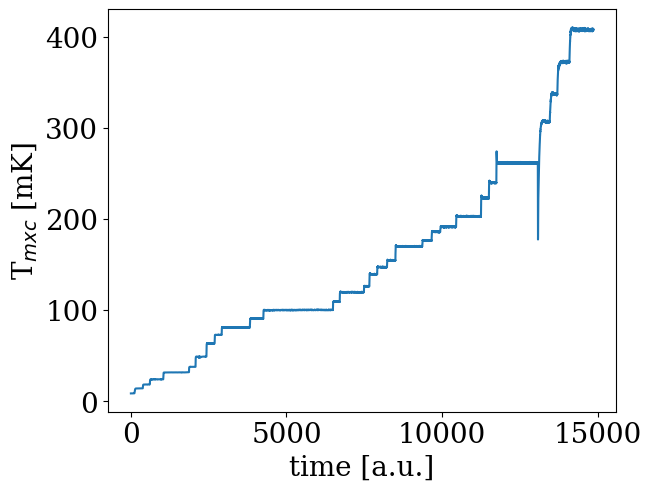

In [3]:
# Load and read temperature data

# Bluefors temperature log
main_folder = r'/media/jc/Elements/bluefors_temperature_log/2024-06'
folders = os.listdir(main_folder)

keyword = 'TEMPERATURE'

# empty arrays for temperature stages
temp_MXC = np.array([])
temp_still = np.array([])
temp_4K = np.array([])
temp_50K = np.array([])
header_names = ["YYMMDD", "HHMMSS", "T"]

# pandas file to save the date
temp = pd.DataFrame()

for folder_idx, folder_name in enumerate(folders):
    
    folder_path = os.path.join(main_folder, folder_name)
    file_names = os.listdir(folder_path)

    for file_name in file_names:
        
        if keyword in file_name:
            
            file_path = os.path.join(folder_path, file_name)
            
            # Read the files and format them
            temp_data = pd.read_csv(file_path, 
                                    header=None,
                                    names = header_names,
                                    parse_dates={"Date":["YYMMDD", "HHMMSS"]},
                                    dayfirst=True,
                                    # date_format='mixed'
                                    )
            
            # sort by temperature plate
            if 'CH1' in file_name:
                temp_50K = np.append(temp_50K, temp_data["T"].to_numpy())
                
            elif 'CH2' in file_name:
                temp_4K = np.append(temp_4K, temp_data["T"].to_numpy())
                
            elif 'CH5' in file_name:
                temp_still = np.append(temp_still, temp_data["T"].to_numpy())
                
            elif 'CH6' in file_name:
                temp = pd.concat([temp, temp_data], ignore_index=True)
                temp_MXC = np.append(temp_MXC, temp_data["T"].to_numpy())

                
# Add room temperature in K
temp_room = np.full(len(temp_50K), 300)
# Add cold plate temperature in K
temp_cold = np.zeros_like(temp_MXC)
for mxc_idx, mxc_val in enumerate(temp_MXC):
    # We make the assumption T_cold = max(100 mK, T_mxc)
    if mxc_val < 0.10:
        temp_cold[mxc_idx] = 0.1
    else:
        temp_cold[mxc_idx] = mxc_val
        

# sometimes temp_i have different sizes and throws an error when stacking them! 
# print(np.shape(temp_MXC), np.shape(temp_cold), np.shape(temp_still), np.shape(temp_4K),  np.shape(temp_50K), np.shape(temp_room))

# Merge all the temperature arrays
temp_plates_arr = np.hstack((temp_room[:, None],
                             temp_50K[:, None], 
                             temp_4K[:, None], 
                             temp_still[:-1, None],
                             temp_cold[:, None],
                             temp_MXC[:, None]))


# Convert array to pandas
headers = ["T room", "T 50K", "T 4K", "T still", "T cold", "T mxc"]
temp_plates_pd = pd.DataFrame(data=temp_plates_arr,
                              columns= headers,
                              )


# Insert dates
temp_plates_pd.insert(0, "Date", temp["Date"])

# Sort pandas file by date
temp_plates_pd.sort_values(by="Date", inplace=True)  # Sort by date
temp_plates_pd.reset_index(drop=True, inplace=True)  # Reset indices

# print(temp_plates_pd)


# Plot mxc temperature as a sanity check
fig, ax = plt.subplots()
ax.plot(temp_plates_pd['T mxc'][:-5000]*1e3)
ax.set_xlabel('time [a.u.]')
ax.set_ylabel(r'T$_{mxc}$ [mK]')
plt.show()

## Error analysis on the calibration data

We measure $N_{pix} = 2.5 \cdot 10^6$ pixels in total, whose mean and standard deviation is given by:

$$ \overline{FS}_{all} = \dfrac{1}{N_{pix}} \sum_i^{N_{pix}} FS_i $$
$$ \sigma_{FS_{all}} = \sqrt{ \dfrac{1}{N_{pix}} \sum_i^{N_{pix}} \left( FS_i - \overline{FS}_{all} \right)^2}$$

The standard deviation of the whole sample is not a good magnitude to characterize the error of the noise. Thus we chunck the data in $N_{chuncks}=1000$ chuncks of $N_{pix,c}=2500$ pixels each. We then calculate the mean and standard deviation of each chunk as:

$$ \overline{FS}_{c} = \dfrac{1}{N_{pix,c}} \sum_i^{N_{pix,c}} FS_i^c $$
$$ \sigma_{FS_{c}} = \sqrt{ \dfrac{1}{N_{pix,c}} \sum_i^{N_{pix,c}} \left( FS_i^c - \overline{FS}_{c} \right)^2}$$

Eventually, we calculate the standard error of the mean as:

$$ \overline{FS} = \dfrac{1}{N_{chuncks}} \sum_c^{N_{chuncks}} \overline{FS}_{c} $$
$$ \sigma_{FS} = \dfrac{1}{\sqrt{N_{chuncks}}} \sum_c^{N_{chunks}} \dfrac{\sigma_{FS}}{N_{chunks}}$$


In [4]:
# Load the raw calibration data 

# True to load the raw data (Takes 1 hour!)
load = False

if load:

    # Load calibration data
    folder = r'/media/jc/Elements/JPA-Data/2024-06/planck_spectroscopy'
    filenames = os.listdir(folder)

    file_path = []
    for file_idx, file_name in enumerate(filenames):
        file_path = np.append(file_path, os.path.join(folder, file_name))

    meas_type = 'planck spectroscopy'

    # Number of temperature stages in our DR
    nr_temp_plates = 6

    # data empty array
    noise_fs = np.zeros((len(file_path), 191))
    noise_fs_std = np.zeros_like(noise_fs)
    noise_uV2 = np.zeros_like(noise_fs)
    noise_uV2_std = np.zeros_like(noise_fs)
    
    noise_fs_i = np.zeros((1000, 191))
    noise_fs_std_i = np.zeros_like(noise_fs_i)
    noise_uV2_i = np.zeros_like(noise_fs_i)
    noise_uV2_std_i = np.zeros_like(noise_fs_i)

    # Empty temperature arrays
    temp_arr = np.zeros((len(file_path), nr_temp_plates))
    temp_std_arr = np.zeros_like(temp_arr)

    # Display nice progress bar
    with tqdm(total=(len(file_path)), ncols=80) as pbar:

        # loop through all the files
        for file_idx, file_name in enumerate(filenames):

            with h5py.File(file_path[file_idx], "r") as dataset:

                # Folder name inside the hdf5 file
                key = list(dataset[meas_type].keys())[0]
                idx_str = "{}/{}".format(meas_type, key)

                # Number of pixels
                Npix = dataset[idx_str].attrs["Npixels"]
                # NCO frequency in Hz
                # fNCO = dataset[idx_str].attrs["fNCO"]
                fNCO =  4.1e9
                # df frequency in Hz
                df = dataset[idx_str].attrs["df"]        


                # Get temperature from the bluefors temperature log
                key = list(dataset[meas_type].keys())[0]
                idx_str = "{}/{}".format(meas_type, key)

                # Measurement start and end time
                t_start_str = dataset[idx_str].attrs["t_start"]
                t_end_str = dataset[idx_str].attrs["t_end"]
                # Change format
                t_start = datetime.strptime(t_start_str, "%Y-%m-%d_%H_%M_%S")
                t_end = datetime.strptime(t_end_str, "%Y-%m-%d_%H_%M_%S")
                # Get indices
                idx_sta = temp_plates_pd.Date.searchsorted(t_start)
                idx_end = temp_plates_pd.Date.searchsorted(t_end)
                # Chunk data
                date_subset_arr = temp_plates_pd.loc[idx_sta:idx_end, "Date"].to_numpy()
                temp_subset_arr = 1e3 * temp_plates_pd.loc[idx_sta:idx_end, headers].to_numpy()

                # Mean temperature and std deviation
                temp_arr[file_idx] = np.mean(temp_subset_arr, axis=0)
                temp_std_arr[file_idx] = np.std(temp_subset_arr, axis=0)


                # Frequency comb
                freqs = np.asarray(dataset[idx_str]["freq comb"])
                IF_usb = freqs - fNCO
                IF_lsb = fNCO - freqs
                freq_arr = np.concatenate((np.flipud(IF_lsb[1:]), IF_usb)) + fNCO

                # Raw data
                usb_arr = np.asarray(dataset[idx_str]["USB"])
                lsb_arr = np.asarray(dataset[idx_str]["LSB"])
                sb_arr = np.concatenate((np.fliplr(lsb_arr[:,1:]), usb_arr), axis=1)

                # Noise power data in uFS²
                N_chunk = 2500
                i = 0
                for n in range(0, Npix, N_chunk):
                    noise_fs_i[i] = np.mean(np.abs(sb_arr[n:n + N_chunk])**2, axis=0) * 1e12
                    noise_fs_std_i[i] = np.std(np.abs(sb_arr[n:n + N_chunk])**2, axis=0) * 1e12
                    
                    # Noise power in uV²
                    noise_dBFS = 20 * np.log10(np.mean(np.abs(sb_arr[n:n + N_chunk]), axis=0))  # dBFS
                    noise_dBm = noise_dBFS + 10.67  # dBm
                    noise_W = 10**((noise_dBm - 30) / 10)  # W
                    noise_V2 = noise_W * 50  # V²
                    noise_uV2_i[i] = noise_V2 * 1e12

                    # Standard deviation of the noise power in uV²
                    noise_dBFS_std = 20 * np.log10(np.std(np.abs(sb_arr[n:n + N_chunk]), axis=0))  # dBFS
                    noise_dBm_std = noise_dBFS_std + 10.67  # dBm
                    noise_W_std = 10**((noise_dBm_std - 30) / 10)  # W
                    noise_V2_std = noise_W_std * 50  # V²
                    noise_uV2_std_i[i] = noise_V2_std * 1e12
                    
                    i += 1
                
                # mean and standard deviation of the mean
                noise_fs[file_idx] = np.mean(noise_fs_i, axis=0)
                noise_fs_std[file_idx] = np.mean(noise_fs_std_i, axis=0) / np.sqrt(1000)
                
                noise_uV2[file_idx] = np.mean(noise_uV2_i, axis=0)
                noise_uV2_std[file_idx] = np.mean(noise_uV2_std_i, axis=0) / np.sqrt(1000)
     
                pbar.update(1)



    # Save data function
    def save_data(folder, file, myrun, freq, intbw, mean_temp, std_temp, mean_fs, std_fs, mean_V2, std_V2):
        if not os.path.isdir(folder):
            os.makedirs(folder)

        # Open the save file (.hdf5) in append mode
        with h5py.File(os.path.join(folder, file), "a") as savefile:
            
            # String as handles
            freq_data_str = "{}/freq arr".format(myrun)
            df_data_str = "{}/df".format(myrun)
            mean_temp_data_str = "{}/mean temp".format(myrun)
            std_temp_data_str = "{}/std temp".format(myrun)
            mean_fs_data_str = "{}/mean fs".format(myrun)
            std_fs_data_str = "{}/std fs".format(myrun)
            mean_V2_data_str = "{}/mean V2".format(myrun)
            std_V2_data_str = "{}/std V2".format(myrun)

            # Write data to datasets
            savefile.create_dataset(freq_data_str, (np.shape(freq)),
                                    dtype=float, data=freq)
            savefile.create_dataset(df_data_str, (np.shape(intbw)),
                                    dtype=float, data=intbw)
            savefile.create_dataset(mean_temp_data_str, (np.shape(mean_temp)),
                                    dtype=float, data=mean_temp)
            savefile.create_dataset(std_temp_data_str, (np.shape(std_temp)),
                                    dtype=float, data=std_temp)
            savefile.create_dataset(mean_fs_data_str, (np.shape(mean_fs)),
                                    dtype=float, data=mean_fs)
            savefile.create_dataset(std_fs_data_str, (np.shape(std_fs)),
                                    dtype=float, data=std_fs)
            savefile.create_dataset(mean_V2_data_str, (np.shape(mean_V2)),
                                    dtype=float, data=mean_V2)
            savefile.create_dataset(std_V2_data_str, (np.shape(std_V2)),
                                    dtype=float, data=std_V2)

            # Write dataset attributes
            savefile[freq_data_str].attrs["Unit"] = "Hz"
            savefile[df_data_str].attrs["Unit"] = "Hz"
            savefile[mean_temp_data_str].attrs["Unit"] = "mK"
            savefile[std_temp_data_str].attrs["Unit"] = "mK"
            savefile[mean_fs_data_str].attrs["Unit"] = "uFS2"
            savefile[std_fs_data_str].attrs["Unit"] = "uFS2"
            savefile[mean_V2_data_str].attrs["Unit"] = "uV2"
            savefile[std_V2_data_str].attrs["Unit"] = "uV2"


    folder_save = r'/media/jc/Elements/JPA-Data'
    file_save = 'planck.hdf5'
    myrun = '2024-06'

    # Sort temperatures
    temp_idx = np.argsort(temp_arr[:,-1])
    temp_arr = temp_arr[temp_idx]
    temp_std_arr = temp_std_arr[temp_idx]
    noise_fs = noise_fs[temp_idx]
    noise_fs_std = noise_fs_std[temp_idx]
    noise_uV2 = noise_uV2[temp_idx]
    noise_uV2_std = noise_uV2_std[temp_idx]

    # Save data
    save_data(folder_save, file_save, myrun, freq_arr, df, temp_arr, temp_std_arr, noise_fs, noise_fs_std, noise_uV2, noise_uV2_std)

In [5]:
# Load processed calibration data

file = r'/media/jc/Elements/JPA-Data/planck.hdf5'
run = '2024-06'
idx_str = "{}".format(run)

with h5py.File(file, "r") as dataset:
    
    # Noise power data in uFS2
    noise_fs = np.asarray(dataset[idx_str]["mean fs"])
    noise_fs_std = np.asarray(dataset[idx_str]["std fs"])
    
    # Noise power data in uV2
    noise_uV2 = np.asarray(dataset[idx_str]["mean V2"])
    noise_uV2_std = np.asarray(dataset[idx_str]["std V2"])
    
    # Temperatures
    temp_arr = np.asarray(dataset[idx_str]["mean temp"])
    temp_std_arr = np.asarray(dataset[idx_str]["std temp"])
    
    # Frequencies
    freq_arr = np.asarray(dataset[idx_str]["freq arr"])
    
    # Integration bandwidth
    df = np.asarray(dataset[idx_str]["df"])


# Number of temperatures and frequencies
nr_temp = len(temp_arr[:, -1])
nr_freq = len(freq_arr)

# Number of temperature stages in our DR
nr_temp_plates = len(temp_arr[0, :])
    
# Conversion factor from FS to V2
factor = np.mean(noise_uV2 / noise_fs)
factor_out = 0.2216  # Believing Elisabet from FSout to dBm

print(factor)

0.45825567384804217


In [6]:
# Load raw calibration data at a single temperature

single = False

if single:
    
    folder = r'/media/jc/Elements/JPA-Data/2023-11/planck_spectroscopy'
    filenames = '2023-11-planck_9mk.hdf5'

    file_path = os.path.join(folder, filenames)

    meas_type = 'planck spectroscopy'

    # Number of temperature stages in our DR
    nr_temp_plates = 6


    with h5py.File(file_path, "r") as dataset:

        # Folder name inside the hdf5 file
        key = list(dataset[meas_type].keys())[0]
        idx_str = "{}/{}".format(meas_type, key)

        # Number of pixels
        Npix = dataset[idx_str].attrs["Npixels"]
        # NCO frequency in Hz
        # fNCO = dataset[idx_str].attrs["fNCO"]
        fNCO =  4.1e9
        # df frequency in Hz
        df = dataset[idx_str].attrs["df"]        

        # Frequency comb
        freqs = np.asarray(dataset[idx_str]["freq comb"])
        IF_usb = freqs - fNCO
        IF_lsb = fNCO - freqs
        freq_arr = np.concatenate((np.flipud(IF_lsb[1:]), IF_usb)) + fNCO

        # Raw data
        usb_arr = np.asarray(dataset[idx_str]["USB"])
        lsb_arr = np.asarray(dataset[idx_str]["LSB"])
        sb_arr = np.concatenate((np.fliplr(lsb_arr[:,1:]), usb_arr), axis=1)

        noise_fs_i = np.zeros((1000, 191))
        noise_fs_std_i = np.zeros_like(noise_fs_i)
        noise_uV2_i = np.zeros_like(noise_fs_i)
        noise_uV2_std_i = np.zeros_like(noise_fs_i)

        # Noise power data in uFS²
        N_chunk = 2500
        i = 0
        for n in range(0, Npix, N_chunk):
            noise_fs_i[i] = np.mean(np.abs(sb_arr[n:n + N_chunk])**2, axis=0) * 1e12
            noise_fs_std_i[i] = np.std(np.abs(sb_arr[n:n + N_chunk])**2, axis=0) * 1e12

            # Noise power in uV²
            noise_dBFS = 20 * np.log10(np.mean(np.abs(sb_arr[n:n + N_chunk]), axis=0))  # dBFS
            noise_dBm = noise_dBFS + 10.67  # dBm
            noise_W = 10**((noise_dBm - 30) / 10)  # W
            noise_V2 = noise_W * 50  # V²
            noise_uV2_i[i] = noise_V2 * 1e12

            # Standard deviation of the noise power in uV²
            noise_dBFS_std = 20 * np.log10(np.std(np.abs(sb_arr[n:n + N_chunk]), axis=0))  # dBFS
            noise_dBm_std = noise_dBFS_std + 10.67  # dBm
            noise_W_std = 10**((noise_dBm_std - 30) / 10)  # W
            noise_V2_std = noise_W_std * 50  # V²
            noise_uV2_std_i[i] = noise_V2_std * 1e12

            i += 1
            
    # Plot         
    x_plot = np.arange(0, Npix, N_chunk)

    fig, ax = plt.subplots(1)

    ax.plot((np.abs(sb_arr[:, 0])**2)*1e12, '.')

    ax.plot(x_plot, noise_fs_i[:, 0], '.', c='orange')
    ax.plot(x_plot, noise_fs_i[:, 0]+noise_fs_std_i[:, 0], '.', c='orange')
    ax.plot(x_plot, noise_fs_i[:, 0]-noise_fs_std_i[:, 0], '.', c='orange')

    ax.axhline(np.mean(np.abs(sb_arr[:, 0])**2)*1e12, c='black')
    ax.axhline((np.mean(np.abs(sb_arr[:, 0])**2)+np.std(np.abs(sb_arr[:, 0])**2))*1e12, c='black')
    ax.axhline((np.mean(np.abs(sb_arr[:, 0])**2)-np.std(np.abs(sb_arr[:, 0])**2))*1e12, c='black')

    ax.axhline(noise_fs[0, 0], c='green')
    ax.axhline(noise_fs[0, 0]+noise_fs_std[0, 0], c='green')
    ax.axhline(noise_fs[0, 0]-noise_fs_std[0, 0], c='green')

    ax.axhline((np.mean(np.abs(sb_arr[:, 0])**2)+np.std(np.abs(sb_arr[:, 0])**2)/np.sqrt(Npix))*1e12, c='black')
    ax.axhline((np.mean(np.abs(sb_arr[:, 0])**2)-np.std(np.abs(sb_arr[:, 0])**2)/np.sqrt(Npix))*1e12, c='black')

    ax.set_ylim([-1000, 20_000])

    plt.show()

We analyze the noise power of a single dataset to make sure we perform the correct statistics.

<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_11251/2011055184.py:15: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('noise power [$\mu FS^2$]')


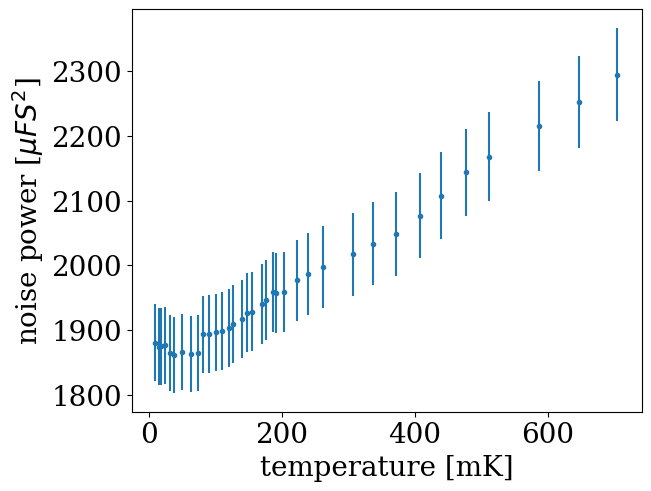

In [7]:
# Plot FS data at a given frequency
freq_ind = 144

fig, ax = plt.subplots(1)

ax.errorbar(temp_arr[:, -1], 
            noise_fs[:, freq_ind], 
            xerr=temp_std_arr[:, -1],
            yerr=noise_fs_std[:, freq_ind], 
            fmt='.', 
            label='measurement',
           )

ax.set_xlabel('temperature [mK]')
ax.set_ylabel('noise power [$\mu FS^2$]')

plt.show()

## Thermal noise fit

Now we need to transform our raw experimental data from FS to V$^2$. 

To do so, we first need to calibrate Presto's output and input ports using a vector network analyzer.
We obtain the following values:

$$ 0.707 \text{FS$_{out}$} = -16.10 \; \text{dBm}, $$
$$ 0.045858 \text{FS$_{in}$} = -16.10 \; \text{dBm}. $$

We then want a relation between dBFS$_{in}$ and dBm, to later convert it to V$^2$. 
In this regard:

$$ 0.045858 \; \text{FS$_{in}$} \;\; \rightarrow \;\; 20 \text{log}_{10}(0.045858)\; \text{dBFS$_{in}$}= -26.77 \; \text{dBFS$_{in}$} $$

$$ -26.77 \; \text{dBFS$_{in}$} = -16.10 \; \text{dBm} \;\; \rightarrow \;\; 0 \; \text{dBFS$_{in}$} = 10.67 \; \text{dBm} $$

$$ P[\text{dBm}] = P_0[\text{dBm}] + 20 \log{\left( \dfrac{A[\text{FS}]}{A_0[\text{FS}]} \right)}$$

Then to convert from dBm to V$^2$ we just convert to W using:

$$ P[\text{W}] = 10^{(P[dBm]-30)/10}, $$

and then to V$^2$ as:

$$ P[\text{V}^2] = P[\text{W}] \cdot R $$

We then obtain the gain and added number of photons of the amplification chain by fitting the Johnson-Nyquist noise expression to our experimental thermal noise data.

In [8]:
# Thermal noise fit

# Initial guess for fit
G0 = 85
n0 = 5

# initialize empty arrays
gain_arr = np.zeros_like(freq_arr)
gain_std_arr = np.zeros_like(gain_arr)
nbar_arr = np.zeros_like(gain_arr)
nbar_std_arr = np.zeros_like(gain_arr)

# Empty arrays for odr optimization
param = np.zeros((len(gain_arr), 2))
param_std = np.zeros_like(param)

# mixing chamber temperature
temp_mxc = temp_arr[:, -1]
temp_mxc_std = temp_std_arr[:, -1]

for freq_idx, freq_val in enumerate(freq_arr):
    
    # Fit to temperature data using odr
    data = RealData(temp_mxc, noise_uV2[:, freq_idx], temp_mxc_std, noise_uV2_std[:, freq_idx])
    model = Model(lambda beta, temp_mxc: thermal_noise_func_odr(beta, temp_mxc, freq_val, df))
    odr = ODR(data, model, [G0, n0])
    
    # least squares optimization
    odr.set_job(fit_type=2)
    output = odr.run()
    
    # Gain and added noise using leastsq optimization
    gain_arr[freq_idx] = output.beta[0]
    gain_std_arr[freq_idx] = output.sd_beta[0]
    nbar_arr[freq_idx] = output.beta[1]
    nbar_std_arr[freq_idx] = output.sd_beta[1]
    
    # odr (orthogonal distance regression) optimization
    odr.set_job(fit_type=0)
    output = odr.run()
    
    # Gain and added noise using odr optimization
    param[freq_idx] = output.beta
    param_std[freq_idx] = output.sd_beta
    


# Plot
def plot_fit(freq_idx_):
    
    gain_val = gain_arr[freq_idx_]  # Gain at a given frequency
    nbar_val = nbar_arr[freq_idx_]  # Added noise at a given freq
    freq_val = freq_arr[freq_idx_]  # Given frequency
    
    # Temperature range for fitting
    temp_fit = np.linspace(1, 700, 1000)    
    noise_fit = thermal_noise_func_odr([gain_val, nbar_val], temp_fit, freq_val, df)  # leastsq
    noise_fit_odr = thermal_noise_func_odr(param[freq_idx_], temp_fit, freq_val, df)  # odr
    
    # Plot fits
    fig = plt.figure(figsize=(14, 5))
    gs = gridspec.GridSpec(2, 2, figure=fig)
    ax = fig.add_subplot(gs[:, 0])
    
    # Experimental data
    ax.errorbar(temp_mxc, 
                noise_uV2[:, freq_idx_], 
                xerr=temp_mxc_std,
                yerr=noise_uV2_std[:, freq_idx_], 
                fmt='.', 
                label='measurement',
               )
    # leastsq fit
    ax.plot(temp_fit, noise_fit, '--', label='fit leastsq')
    # odr fit
    # ax.plot(temp_fit, noise_fit_odr, '--', label='fit odr')
    ax.set_xlabel('temperature [mK]')
    ax.set_ylabel('noise power [$\mu V^2$]')
    ax.legend()
    
    # Gain
    ax_gain = fig.add_subplot(gs[0, 1])
    ax_gain.errorbar(freq_arr[:-1]/1e9, gain_arr[:-1], yerr=gain_std_arr[:-1], fmt='.', label='leastsq')
    # ax_gain.errorbar(freq_arr[:-1]/1e9, param[:-1, 0], yerr=param_std[:-1, 0], fmt='.', label='odr')
    ax_gain.axvline(freq_val/1e9, color='black', linestyle='--')
    ax_gain.set_ylabel('gain [dB]')
    
    # Added noise
    ax_n = fig.add_subplot(gs[1, 1])
    ax_n.errorbar(freq_arr[:-1]/1e9, nbar_arr[:-1], yerr=nbar_std_arr[:-1], fmt='.', label='leastsq')
    # ax_n.errorbar(freq_arr[:-1]/1e9, param[:-1, 1], yerr=param_std[:-1, 1], fmt='.', label='odr')
    ax_n.axvline(freq_val/1e9, color='black', linestyle='--')
    ax_n.set_xlabel(r'frequency [GHz]')
    ax_n.set_ylabel(r'$\bar{n}$')

    
# Interactive layout  
widgets.interact(plot_fit,
                 freq_idx_=widgets.IntSlider(min=0,
                                             max=len(freq_arr)-2,
                                             step=1,
                                             description='freq ind',
                                             )
                )

plt.show()

<>:78: SyntaxWarning: invalid escape sequence '\m'
<>:78: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_11251/332567287.py:78: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('noise power [$\mu V^2$]')


interactive(children=(IntSlider(value=0, description='freq ind', max=189), Output()), _dom_classes=('widget-in…

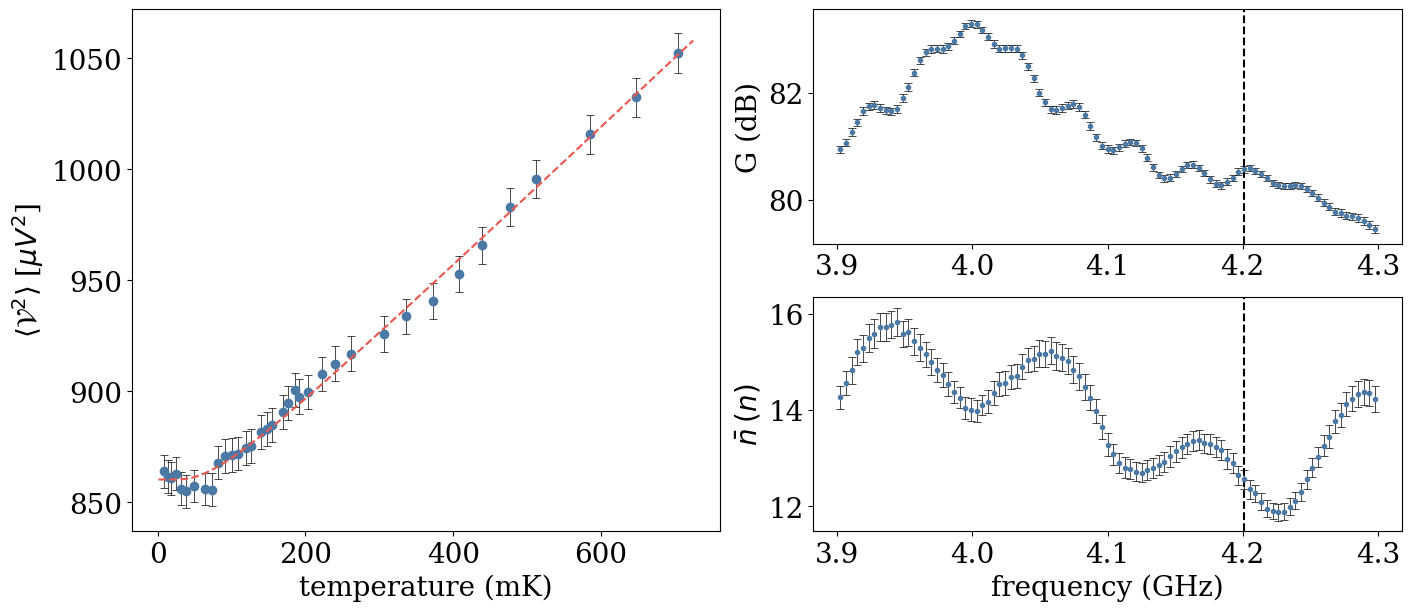

In [9]:
def plot_fit_single(freq_idx_):
    
    gain_val = gain_arr[freq_idx_]  # Gain at a given frequency
    nbar_val = nbar_arr[freq_idx_]  # Added noise at a given freq
    freq_val = freq_arr[freq_idx_]  # Given frequency
    
    # Temperature range for fitting
    temp_fit = np.linspace(1, 725, 1000)    
    noise_fit = thermal_noise_func_odr([gain_val, nbar_val], temp_fit, freq_val, df)  # leastsq
    
    # Plot fits
    fig = plt.figure(figsize=(14, 6))
    gs = gridspec.GridSpec(2, 2, figure=fig)
    ax = fig.add_subplot(gs[:, 0])
    
    # Experimental data
    ax.errorbar(temp_mxc, 
                noise_uV2[:, freq_idx_], 
                xerr=temp_mxc_std,
                yerr=noise_uV2_std[:, freq_idx_], 
                fmt='o',
                mfc='#4B79A5',
                c='#4B79A5',
                capsize=3,
                ecolor='black', 
                elinewidth=0.5,
                capthick=0.5,
               )
    # leastsq fit
    ax.plot(temp_fit, noise_fit, '--', c='#ED564E', zorder=2.1)

    ax.set_xlabel('temperature (mK)')
    ax.set_ylabel(r'$\langle \mathcal{V}^2 \rangle$ [$\mu V^2$]')
    # ax.legend()
    
    # Gain
    ax_gain = fig.add_subplot(gs[0, 1])
    ax_gain.errorbar(freq_arr[1::2]/1e9, gain_arr[1::2], yerr=gain_std_arr[1::2], fmt='.', c='#4B79A5', capsize=3, ecolor='black', 
                elinewidth=0.5,
                capthick=0.5)
    ax_gain.axvline(freq_val/1e9, color='black', linestyle='--')
    ax_gain.set_ylabel(r'G (dB)')
    
    # Added noise
    ax_n = fig.add_subplot(gs[1, 1])
    ax_n.errorbar(freq_arr[1::2]/1e9, nbar_arr[1::2], yerr=nbar_std_arr[1::2], fmt='.', c='#4B79A5', capsize=3, ecolor='black', 
                elinewidth=0.5,
                capthick=0.5)
    ax_n.axvline(freq_val/1e9, color='black', linestyle='--', zorder=1.9)
    ax_n.set_xlabel(r'frequency (GHz)')
    ax_n.set_ylabel(r'$\bar{n} \: (n)$')

plot_fit_single(freq_idx_=143)
# plt.savefig(r'/home/jc/OneDrive/PhD/Documents/Papers/Continuous-variable square-ladder cluster state in a microwave frequency comb/Figures/FigA1/planck-v2.pdf', 
#             format='pdf', dpi=600)

## Temperature correction

In a coaxial cable connecting room temperature electronics to base temperature circuits, thermal photons propagate down the line towards the lower temperature stages. To reduce the spectral density of thermal radiation a series of attenuators is installed in the microwave line. An attenuator with an attenuation of A = 20 dB = 100 eﬀectively acts as a beamsplitter which transmits 1% of the incident signal and adds 99% of blackbody radiation with the eﬀective temperature $T_{att}$ at which the attenuator is thermalized.

The effective temperature $T_i^{eff}$ can be calculated as:

$$ T_i^{eff} = T_{i-1}^{eff} 10^{A_i/10} + T_i \left( 1-10^{A_i/10} \right), $$

where $T_{i-1}^{eff}$ is the effective temperature of the previous temperature stage, $A_i$ represents the attenuation at the current temperature stage, and $T_i$ the measured temperature at the current temperature stage.


The effective temperature is between 1.5 and 2.45 mK higher with respect to the measured by the DR.

In [10]:
# Attenuation on every temperature stage
att_arr = np.array([0.1, 0.1, 0.1, 0.1, 0.01])

# Effective temperature
temp_mxc_eff = temp_arr[:, 0]
temp_mxc_eff_std = temp_std_arr[:, 0]
for temp_plate in range(nr_temp_plates-1):
    temp_mxc_eff = temp_mxc_eff * att_arr[temp_plate] + temp_arr[:, temp_plate+1] * (1 - att_arr[temp_plate])
    temp_mxc_eff_std = np.sqrt((temp_mxc_eff_std * att_arr[temp_plate])**2 + 
                               (temp_std_arr[:, temp_plate+1] * (1 - att_arr[temp_plate]))**2)


print(temp_mxc_eff - temp_mxc)

[2.49220208 2.43725738 2.39472489 2.33852894 2.26228503 2.20194461
 2.09158815 1.94798867 1.85569196 1.77314674 1.67903843 1.58552044
 1.57778512 1.56892841 1.56333559 1.55203134 1.54559686 1.5396469
 1.52712913 1.52242251 1.51420198 1.50987369 1.50066208 1.4833171
 1.46932442 1.45316477 1.80962595 1.77975349 1.73662609 1.69599812
 1.66263217 1.62483398 1.58916227 1.5034586  1.44551484 1.39166588]


We then repeat the same fit to the thermal noise expression but using the effective temperature of the attenuator instead.

In [11]:
# Thermal noise fit using the effective temperatures

# Initial guess for fit
G0 = 85
n0 = 10

# initialize empty arrays
gain_eff_arr = np.zeros_like(freq_arr)
gain_eff_std_arr = np.zeros_like(gain_eff_arr)
nbar_eff_arr = np.zeros_like(gain_eff_arr)
nbar_eff_std_arr = np.zeros_like(gain_eff_arr)
gn_corr_arr = np.zeros_like(gain_eff_arr)

# Empty arrays for odr optimization
param_eff = np.zeros((len(gain_eff_arr), 2))
param_eff_std = np.zeros_like(param_eff)

for freq_idx, freq_val in enumerate(freq_arr):
    
    # Fit to temperature data using curve_fit
    popt, pcov = curve_fit(lambda temp_mxc_eff, Gsignal, n: thermal_noise_func(temp_mxc_eff, Gsignal, n, freq_val, df),
                           temp_mxc_eff,
                           noise_uV2[:, freq_idx],
                           p0=(G0, n0),
                           sigma=noise_uV2_std[:, freq_idx],
                           )
    
    # Gain and added noise using leastsq optimization
    gain_eff_arr[freq_idx] = popt[0]
    nbar_eff_arr[freq_idx] = popt[1]
    perr = np.sqrt(np.diag(pcov))
    gain_eff_std_arr[freq_idx] = perr[0]
    nbar_eff_std_arr[freq_idx] = perr[1]
    gn_corr_arr[freq_idx] = pcov[0,1]
    
    # Fit to temperature data using odr
    temp_cutoff = -11
    data = RealData(temp_mxc_eff[temp_cutoff:], noise_uV2[temp_cutoff:, freq_idx], temp_mxc_eff_std[temp_cutoff:], noise_uV2_std[temp_cutoff:, freq_idx])
    model = Model(lambda beta, temp_mxc_eff: thermal_noise_func_odr(beta, temp_mxc_eff, freq_val, df))
    odr = ODR(data, model, [G0, n0])
    
    # odr optimization (least square method)
    odr.set_job(fit_type=2)
    output = odr.run()
    
    # Gain and added noise using odr optimization
    param_eff[freq_idx] = output.beta
    param_eff_std[freq_idx] = output.sd_beta


# Plot
def plot_fit(freq_idx_):
    
    gain_val = gain_eff_arr[freq_idx_]  # Gain at a given frequency
    nbar_val = nbar_eff_arr[freq_idx_]  # Added noise at a given freq
    freq_val = freq_arr[freq_idx_]  # Given frequency
    
    # Temperature range for fitting
    temp_fit = np.linspace(1, 700, 1000)
    noise_fit = thermal_noise_func(temp_fit, gain_val, nbar_val, freq_val, df)  # leastsq
    noise_fit_odr = thermal_noise_func_odr(param_eff[freq_idx_], temp_fit, freq_val, df)  # least square but only high T
    
    # Plot fits
    fig = plt.figure(figsize=(14, 5))
    gs = gridspec.GridSpec(2, 2, figure=fig)
    ax = fig.add_subplot(gs[:, 0])
    
    ax.errorbar(temp_mxc_eff, 
                noise_uV2[:, freq_idx_],
                xerr=temp_mxc_eff_std,
                yerr=noise_uV2_std[:, freq_idx_], 
                fmt='.', 
                label='measurement',
               )
    # leastsq fit
    ax.plot(temp_fit, noise_fit, '--', label='fit leastsq')
    # odr fit
    ax.plot(temp_fit, noise_fit_odr, '--', label='high T')
    ax.axvline(temp_mxc_eff[temp_cutoff], ls='--', c='black')
    ax.set_xlabel('temperature [mK]')
    ax.set_ylabel('noise power [$\mu V^2$]')
    ax.legend()
    
    # Gain
    ax_gain = fig.add_subplot(gs[0, 1])
    ax_gain.errorbar(freq_arr[:-1]/1e9, gain_eff_arr[:-1], yerr=gain_eff_std_arr[:-1], fmt='.', label='leastsq')
    ax_gain.errorbar(freq_arr[:-1]/1e9, param_eff[:-1, 0], yerr=param_eff_std[:-1, 0], fmt='.', label='high T')
    ax_gain.axvline(freq_val/1e9, color='black', linestyle='--')
    ax_gain.set_ylabel('gain [dB]')
    
    # Added noise
    ax_n = fig.add_subplot(gs[1, 1])
    ax_n.errorbar(freq_arr[:-1]/1e9, nbar_eff_arr[:-1], yerr=nbar_eff_std_arr[:-1], fmt='.', label='leastsq')
    ax_n.errorbar(freq_arr[:-1]/1e9, param_eff[:-1, 1], yerr=param_eff_std[:-1, 1], fmt='.', label='high T')
    ax_n.axvline(freq_val/1e9, color='black', linestyle='--')
    ax_n.set_xlabel(r'frequency [GHz]')
    ax_n.set_ylabel(r'$\bar{n}$')

# Interactive layout  
widgets.interact(plot_fit,
                 freq_idx_=widgets.IntSlider(min=0,
                                             max=len(freq_arr)-2,
                                             step=1,
                                             description='freq ind',
                                             )
                )

plt.show()

<>:81: SyntaxWarning: invalid escape sequence '\m'
<>:81: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_11251/3305801892.py:81: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('noise power [$\mu V^2$]')


interactive(children=(IntSlider(value=0, description='freq ind', max=189), Output()), _dom_classes=('widget-in…

We plot the difference between the gain and added number of photons between using the effective temperatures and the directly measured ones.

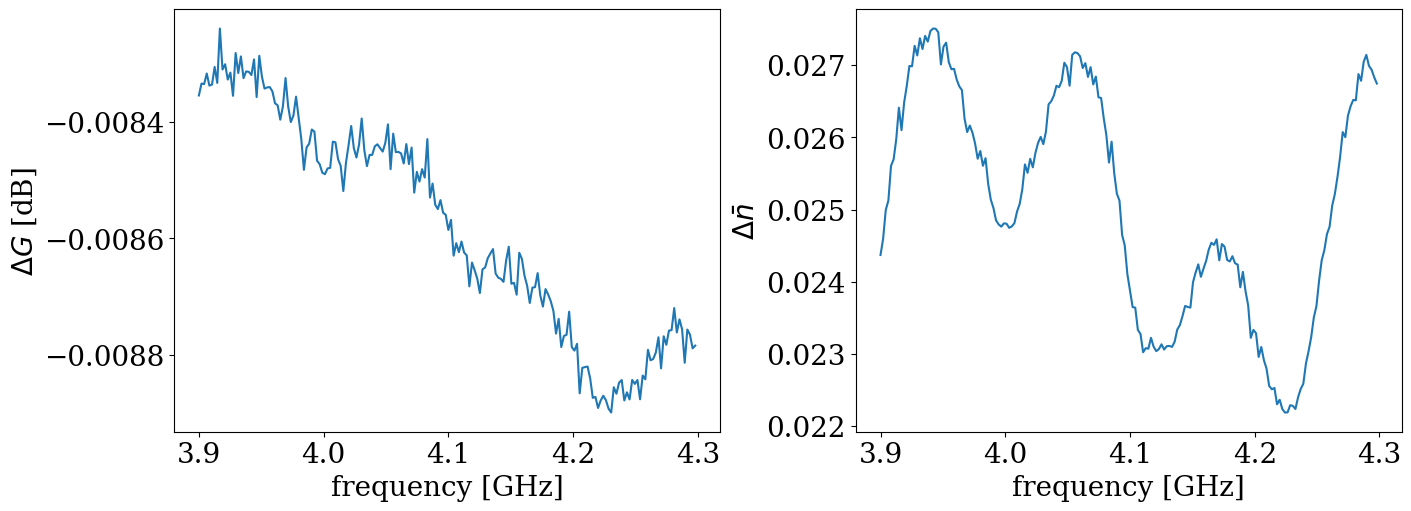

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(freq_arr[:-1]/1e9, gain_eff_arr[:-1]-gain_arr[:-1])
ax[0].set_xlabel(r'frequency [GHz]')
ax[0].set_ylabel(r'$\Delta G$ [dB]')

ax[1].plot(freq_arr[:-1]/1e9, nbar_eff_arr[:-1]-nbar_arr[:-1])
ax[1].set_xlabel(r'frequency [GHz]')
ax[1].set_ylabel(r'$\Delta \bar{n}$')

plt.show()

We now save the gain $G$ and added number of photons $\bar{n}$ as a function of frequency.

In [13]:
# Open the save file (.hdf5) in append mode
save = False

if save:
    
    with h5py.File(file, "a") as dataset:

        # String as handles
        gain_data_str = "{}/gain".format(run)
        std_gain_data_str = "{}/std gain".format(run)
        n_data_str = "{}/n".format(run)
        std_n_data_str = "{}/std n".format(run)
        std_gn_data_str = "{}/std g-n".format(run)

        # Write data to datasets
        dataset.create_dataset(gain_data_str, (np.shape(gain_eff_arr)),
                               dtype=float, data=gain_eff_arr)
        dataset.create_dataset(std_gain_data_str, (np.shape(gain_eff_std_arr)),
                               dtype=float, data=gain_eff_std_arr)
        dataset.create_dataset(n_data_str, (np.shape(nbar_eff_arr)),
                               dtype=float, data=nbar_eff_arr)
        dataset.create_dataset(std_n_data_str, (np.shape(nbar_eff_std_arr)),
                               dtype=float, data=nbar_eff_std_arr)
        dataset.create_dataset(std_gn_data_str, (np.shape(gn_corr_arr)),
                               dtype=float, data=gn_corr_arr)

        # Write dataset attributes
        dataset[gain_data_str].attrs["Unit"] = "dB"
        dataset[std_gain_data_str].attrs["Unit"] = "dB"
        dataset[n_data_str].attrs["Unit"] = "n"
        dataset[std_n_data_str].attrs["Unit"] = "n"
        dataset[std_gn_data_str].attrs["Unit"] = "n"
